All major Imports

In [2]:
# ── Full Reload, Retrain & Back-test (with Morning/Afternoon window) ────────────────────────
import pandas as pd
#import algo.features as feat_mod
#import algo.model    as model_mod
#importlib.reload(feat_mod); importlib.reload(model_mod)

from algo.features import FEATURES
from algo.model import load_or_train, predict_last, LOOKBACK
from algo.broker import KiteWrapper
from algo.config import load_config
from algo.backtester import backtest

[broker] loaded from /Users/sreejit/PycharmProjects/zerodha-bot/algo/broker.py


Data preparation

In [3]:
# 1️⃣ Pull 200 days of 3-min history and build features
cfg      = load_config()
broker   = KiteWrapper(cfg)
#hist_all = broker.history(days=200, interval="3minute",
 #                         tradingsymbol="IDEA")
#df_all   = add_indicators(hist_all, debug=True).ffill()
df_all = pd.read_csv("data_processed/HDFCBANK_3minute_feat.csv",index_col=0,parse_dates=True)
# 2️⃣ Split by *calendar days* instead of raw row count
n_test_days = 20
cutoff      = df_all.index[-1] - pd.Timedelta(days=n_test_days)
df_tr       = df_all[df_all.index <  cutoff]
df_te       = df_all[df_all.index >= cutoff]

print(f"Training rows: {len(df_tr):,}")
print(f"Testing  rows: {len(df_te):,}  (need ≥ {LOOKBACK})")

[KiteWrapper] initialized: symbol=RELIANCE on exch=NSE
Training rows: 40,319
Testing  rows: 1,751  (need ≥ 30)


Model training

In [4]:
# 3️⃣ (Re)train the model
model = load_or_train(df_all, retrain=False,horizon=5)

# 4️⃣ Inspect the pipeline
print("\n▶️ Pipeline steps:", model.named_steps)
lgb = model.named_steps["lgb"]
print("▶️ Final estimator:", lgb)
print("▶️ n_features_in_:", lgb.n_features_in_)
print(f"▶️ Expected      : {len(FEATURES)} × {LOOKBACK} = {len(FEATURES)*LOOKBACK}\n")


▶️ Pipeline steps: {'imputer': SimpleImputer(), 'lgb': LGBMClassifier(colsample_bytree=0.7023760690478573,
               learning_rate=0.017537607442521964, max_depth=5, metric='auc',
               min_child_samples=96, n_estimators=1050, n_jobs=-1,
               num_leaves=76, random_state=0, reg_alpha=1.6898034700530933,
               reg_lambda=1.9674841696814904, subsample=0.9284965223502559,
               verbose=-1)}
▶️ Final estimator: LGBMClassifier(colsample_bytree=0.7023760690478573,
               learning_rate=0.017537607442521964, max_depth=5, metric='auc',
               min_child_samples=96, n_estimators=1050, n_jobs=-1,
               num_leaves=76, random_state=0, reg_alpha=1.6898034700530933,
               reg_lambda=1.9674841696814904, subsample=0.9284965223502559,
               verbose=-1)
▶️ n_features_in_: 600
▶️ Expected      : 20 × 30 = 600



Windowed session

In [5]:
# ── NEW: apply trading-window filter ───────────────────────────────────────────
# Morning session: 09:15–11:30, Afternoon session: 12:30–15:25
df_morning   = df_te.between_time("09:15", "11:30")
df_afternoon = df_te.between_time("12:30", "15:30")
df_windowed  = pd.concat([df_morning, df_afternoon]).sort_index()

Run backtest simulation

In [6]:
# 5️⃣ Run back-test on windowed data only
trades, metrics = backtest(
    df_windowed,
    model=model,
    capital=2000000,
    contract_size=1,
    sl_pct=0.0015,
    tp_pct=0.0030,
    trail_pct=0.0010,
    hold_max=10,
    upper=0.53,
    lower=0.47,
    predict_fn=predict_last,
    hold_min=0,
    debug=True,
)

# 6️⃣ Review results
#print("Back-test metrics:", metrics)
#print("\nFirst few trades:\n", trades.head())

[backtest] raw df shape: (1485, 25)
[backtest] columns: ['open', 'high', 'low', 'close', 'volume', 'volatility_5', 'volatility_10', 'high_low_range', 'hour', 'ret1', 'ret5', 'ema_8', 'vwap', 'vol_change', 'rsi_14', 'macd', 'macd_signal', 'supertrend', 'supertrend_dir', 'bb_width', 'stoch_k', 'williams_r', 'atr', 'adx', 'zscore_volume']
[backtest] index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>, freq: None
                       open    high     low   close  volume  volatility_5  \
date                                                                        
2025-06-18 15:27:00  1932.0  1934.1  1931.0  1932.5   85726      0.001152   
2025-06-19 09:15:00  1933.9  1939.0  1925.6  1929.8  177750      0.001269   
2025-06-19 09:18:00  1929.8  1930.3  1927.5  1929.6  133914      0.000852   
2025-06-19 09:21:00  1930.0  1933.5  1929.7  1932.1   69906      0.000996   
2025-06-19 09:24:00  1932.0  1935.3  1932.0  1935.3   45376      0.001210   

                     volatility_1

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/

[backtest] scaled prob stats: min=0.000, max=1.000, mean=0.472
2025-06-19 10:39:00 SKIP short — price above VWAP
2025-06-19 10:42:00 SKIP short — price above VWAP
2025-06-19 10:45:00 SKIP short — price above VWAP
2025-06-19 10:48:00 SKIP short — price above VWAP
2025-06-19 10:51:00 SKIP short — price above VWAP
2025-06-19 10:54:00 SKIP short — price above VWAP
2025-06-19 10:57:00 SKIP short — price above VWAP
2025-06-19 11:06:00 SKIP short — price above VWAP
2025-06-19 11:09:00 SKIP short — price above VWAP
2025-06-19 11:12:00 SKIP short — price above VWAP
2025-06-19 11:15:00 SKIP TRADE — low expected gain (0.00015) vs fee (0.00020)
2025-06-19 11:18:00 SIGNAL SELL @ prob=0.421
2025-06-19 11:18:00 ENTRY SELL @ qty=516 price=1937.50

[fees] entry=1937.50, exit=1935.90, qty=516
[fees]  > turnover=1998674.40, brokerage(total)=40.00 (per leg=20.00), txn=64.9569, sebi=0.9993, stt=249.7311, gst=18.8922, stamp=29.9925
[fees]  >> total fees=404.5721

2025-06-19 12:30:00 EXIT TIME SELL @ price=1

Backtest results

In [7]:
print("Back-test metrics:", metrics)

Back-test metrics: {'Signals': 74, 'Trades': 74, 'WinRate': 0.3918918918918919, 'GrossPnL': 6485.236149999321, 'Fees': 29852.03833411959, 'NetPnL': -23366.802184120268, 'EquityFinal': 1976633.1978158785}


Backtest trades log

In [8]:
trades

,exit_ts,side,entry_price,exit_price,exit_reason,fees,qty,pnl,equity
entry_ts,,,,,,,,,
2025-07-08 09:36:00,2025-07-08 10:06:00,BUY,1986.6,1986.8000,TIME,118.266459,100,-98.266459,199901.733541
2025-07-08 10:09:00,2025-07-08 10:39:00,BUY,1987.0,1988.9000,TIME,118.329872,100,71.670129,199973.403669
2025-07-08 10:42:00,2025-07-08 14:30:00,BUY,1988.0,1991.9760,TP,118.425607,100,279.174393,200252.578063
2025-07-08 14:33:00,2025-07-08 14:39:00,BUY,1996.0,1993.0060,SL,118.510438,100,-417.910438,199834.667624
2025-07-08 14:42:00,2025-07-08 14:54:00,BUY,1992.1,1996.0842,TP,118.572501,100,279.847499,200114.515124
2025-07-08 14:57:00,2025-07-08 15:27:00,BUY,1999.8,1999.4000,TIME,118.721292,100,-158.721292,199955.793832


Optuna hyperparameter tuning

In [12]:
import optuna
from sklearn.metrics import roc_auc_score
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import lightgbm as lgb
import numpy as np


# Load your feature-ready CSV
df = pd.read_csv("data_processed/HDFCBANK_3minute_feat.csv", index_col=0, parse_dates=True)

LOOKBACK = 60
HORIZON = 5  # ✅ Predict return over next 5 bars

# ---------------------------- Sliding Window & Label Prep ----------------------------
def _make_sliding_X_named(df, lookback):
    win = len(FEATURES)
    arr = df[FEATURES].to_numpy("float64")
    view = np.lib.stride_tricks.sliding_window_view(arr, (lookback, win))
    X = view.reshape(view.shape[0], -1)
    col_names = [f"{feat}_t{lookback - t}" for t in range(lookback) for feat in FEATURES]
    return pd.DataFrame(X, columns=col_names)

def _prepare_xy_named(df, lookback, horizon, return_threshold=0.001, vol_threshold=0.0005):
    df = df.copy()

    # Step 1: Calculate future return for label
    df["future_return"] = df["close"].pct_change(periods=horizon).shift(-horizon)

    # Step 2: Add volatility and filter low-vol periods
    df["volatility"] = df["close"].pct_change().rolling(20).std()
    df = df[df["volatility"] > vol_threshold]  # filter low-volatility rows

    # Create sliding feature matrix
    X_df = _make_sliding_X_named(df, lookback)[:-horizon]

    # Apply return threshold to define label
    y_raw = df["future_return"]
    y = (y_raw.iloc[lookback - 1 : -horizon] > return_threshold).astype(int).to_numpy()

    # Clean any NaN/infinite rows
    mask = np.isfinite(X_df).all(axis=1)
    return X_df[mask], y[mask]


# ---------------------------- Optuna Objective ----------------------------
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 2.0),
        'metric': 'auc',
        'random_state': 0,
        'n_jobs': -1,
        'verbose': -1
    }

    X, y = _prepare_xy_named(df, LOOKBACK, HORIZON)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

    imputer = SimpleImputer(strategy="mean")
    X_train = imputer.fit_transform(X_train)
    X_val = imputer.transform(X_val)

    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(100)]
    )

    preds = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, preds)

# ---------------------------- Run Optuna ----------------------------
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# ---------------------------- Output ----------------------------
print("Best params:", study.best_params)
print("Best AUC:", study.best_value)


[I 2025-07-11 10:16:34,269] A new study created in memory with name: no-name-3d9d8abd-b5bb-4d60-9c51-f7278e0da6b6


Training until validation scores don't improve for 100 rounds


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2025-07-11 10:16:47,162] Trial 0 finished with value: 0.5647626304333637 and parameters: {'n_estimators': 1231, 'learning_rate': 0.06924472145269564, 'num_leaves': 125, 'max_depth': 9, 'min_child_samples': 90, 'subsample': 0.8645575483164363, 'colsample_bytree': 0.9870471249438801, 'reg_alpha': 1.7812973698508483, 'reg_lambda': 1.0504816010091762}. Best is trial 0 with value: 0.5647626304333637.


Early stopping, best iteration is:
[27]	valid_0's auc: 0.564763
Training until validation scores don't improve for 100 rounds


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2025-07-11 10:16:53,537] Trial 1 finished with value: 0.5842777957506464 and parameters: {'n_estimators': 1443, 'learning_rate': 0.009250105715909649, 'num_leaves': 23, 'max_depth': 4, 'min_child_samples': 29, 'subsample': 0.7306214829299628, 'colsample_bytree': 0.9268554274098564, 'reg_alpha': 0.5778737344364002, 'reg_lambda': 0.8302100213562311}. Best is trial 1 with value: 0.5842777957506464.


...

Early stopping, best iteration is:
[100]	valid_0's auc: 0.577435
Training until validation scores don't improve for 100 rounds


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2025-07-11 10:25:12,665] Trial 48 finished with value: 0.5869653308095643 and parameters: {'n_estimators': 668, 'learning_rate': 0.015878269071760064, 'num_leaves': 86, 'max_depth': 4, 'min_child_samples': 92, 'subsample': 0.8852046893654419, 'colsample_bytree': 0.6921538291969632, 'reg_alpha': 1.7709104784881189, 'reg_lambda': 1.8537242298929613}. Best is trial 29 with value: 0.5937107730319946.


Early stopping, best iteration is:
[50]	valid_0's auc: 0.586965
Training until validation scores don't improve for 100 rounds


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2025-07-11 10:25:21,574] Trial 49 finished with value: 0.581694668868816 and parameters: {'n_estimators': 1537, 'learning_rate': 0.0525752992638034, 'num_leaves': 75, 'max_depth': 10, 'min_child_samples': 85, 'subsample': 0.9222008596632922, 'colsample_bytree': 0.6612090445655252, 'reg_alpha': 1.9572036538396291, 'reg_lambda': 1.9985547676060726}. Best is trial 29 with value: 0.5937107730319946.


Early stopping, best iteration is:
[8]	valid_0's auc: 0.581695
Best params: {'n_estimators': 1050, 'learning_rate': 0.017537607442521964, 'num_leaves': 76, 'max_depth': 5, 'min_child_samples': 96, 'subsample': 0.9284965223502559, 'colsample_bytree': 0.7023760690478573, 'reg_alpha': 1.6898034700530933, 'reg_lambda': 1.9674841696814904}
Best AUC: 0.5937107730319946


Feature importance

[LightGBM] [Info] Number of positive: 16558, number of negative: 17047
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.155066 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 237720
[LightGBM] [Info] Number of data points in the train set: 33605, number of used features: 1050
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.492724 -> initscore=-0.029105
[LightGBM] [Info] Start training from score -0.029105
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

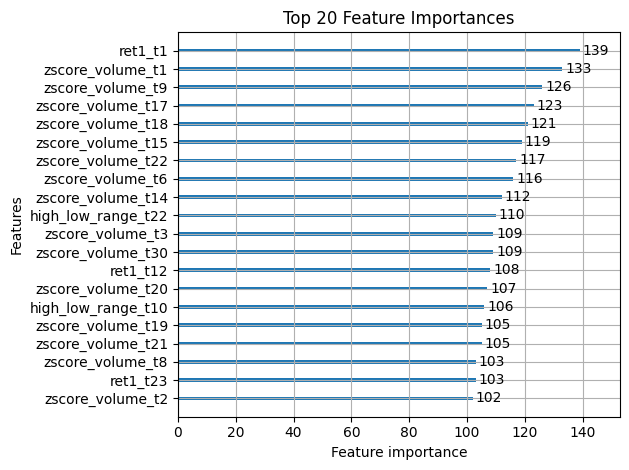

In [1]:
import pandas as pd
from algo.features import FEATURES
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np

# Load and prepare your dataset
df_feat = pd.read_csv("data_processed/HDFCBANK_3minute_feat.csv", index_col=0, parse_dates=True)


LOOKBACK = 30

# Create sliding window X with column names
def _make_sliding_X_named(df):
    win = len(FEATURES)
    arr = df[FEATURES].to_numpy("float64")
    view = np.lib.stride_tricks.sliding_window_view(arr, (LOOKBACK, win))
    X = view.reshape(view.shape[0], -1)
    col_names = [f"{feat}_t{LOOKBACK - t}" for t in range(LOOKBACK) for feat in FEATURES]
    return pd.DataFrame(X, columns=col_names)

def _prepare_xy_named(df):
    df = df.copy()
    df["ret1"] = df["close"].pct_change()
    X_df = _make_sliding_X_named(df)[:-1]
    y_raw = df["ret1"].shift(-1)
    y = (y_raw.iloc[LOOKBACK - 1 : -1] > 0).astype(int).to_numpy()
    mask = np.isfinite(X_df).all(axis=1)
    return X_df[mask], y[mask]

# Prepare training data
X, y = _prepare_xy_named(df_feat)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

# Impute missing values
imputer = SimpleImputer(strategy="mean")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)

# Train model with best parameters
best_params = {
    'n_estimators': 643,
    'learning_rate': 0.09078979499420385,
    'num_leaves': 99,
    'max_depth': 7,
    'min_child_samples': 51,
    'subsample': 0.8401671337355389,
    'colsample_bytree': 0.7735423356459749,
    'reg_alpha': 0.3319893657790154,
    'reg_lambda': 0.25904857731820763,
    'random_state': 0,
    'n_jobs': -1
}

model = lgb.LGBMClassifier(**best_params)
model.fit(X_train, y_train)

# Plot feature importance with names
lgb.plot_importance(model, max_num_features=20)
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()


In [4]:
corr_matrix = df_feat[[ "zscore_volume", "volume", "volume_lag_1", "volume_lag_5"]].corr()
print(corr_matrix)

               zscore_volume    volume  volume_lag_1  volume_lag_5
zscore_volume       1.000000  0.205345      0.089175     -0.003859
volume              0.205345  1.000000      0.845216      0.467989
volume_lag_1        0.089175  0.845216      1.000000      0.560263
volume_lag_5       -0.003859  0.467989      0.560263      1.000000


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load a small chunk if full dataset is large
sample = df_feat[FEATURES].dropna().copy()

# Optional: limit rows to speed up
sample = sample.tail(5000)


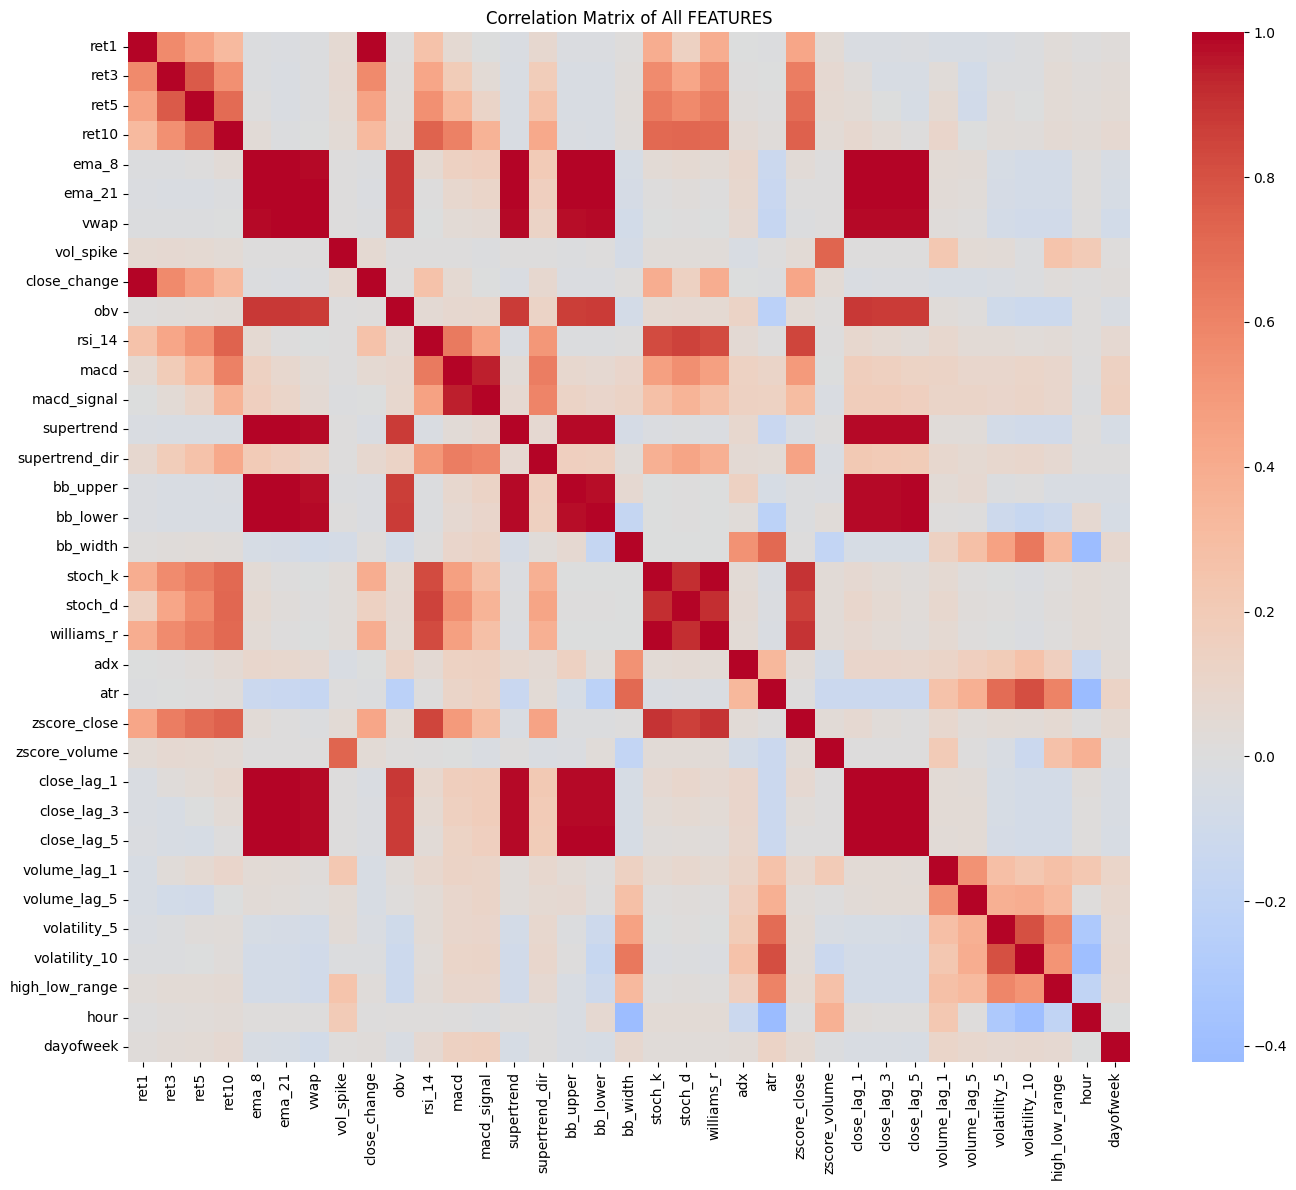

In [7]:
corr_matrix = sample.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of All FEATURES")
plt.tight_layout()
plt.show()
